<a href="https://colab.research.google.com/github/ReemaSaif/Applied-AI-Bootcamp-SDAIA/blob/main/WEEK%202/Projects/project%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Exam Performance Analysis

## Scenario
This dataset show the student-related academic, lifestyle, and socio-enconmic factores that include exam perdormance. It include study hours, student attendence, sleep hours, motivation, tutoring sessions, parental involvement, school type and other environmental features. The main target varibale is Exam_Score which represents the student final exam score.

* Rows: 6607
* Columns: 20


## Goal
The goal of this project is to understand which academic, lifestyle, and socio‑economic **factors most strongly influence students’ final exam scores**, and to quantify these relationships using exploratory data analysis and statistical testing.


## Key Questions
* Which factors have the strongest impact on students’ final exam scores?
* Do academic behaviors like study hours, attendance, and tutoring improve performance?
* How do lifestyle factors such as sleep, stress, and health habits affect exam score?
* Do socio‑economic or environmental conditions contribute to performance differences among students?


## Scope
This analysis uses a dataset of 6,607 students containing academic, lifestyle, and socio‑economic factors to understand what drives variation in final exam performance. The notebook covers basic data cleaning, exploratory analysis, and statistical testing to evaluate the impact of different factors on exam scores and finish with key insights and recommendations.

#️Setup Code:

In [1]:
# Standard libraries
from pathlib import Path

# Installed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import pearsonr

# Configuration
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

# Paths
DATA_PATH = Path('../data/raw/')
OUTPUT_PATH = Path('../output/')

# Data Loading & Quick Validation:

We load the dataset and perform quick validation checks to ensure:
- Dataset is loaded correctly
- Column names and types are as expected


In [2]:
student_exam = pd.read_csv("/content/StudentPerformanceFactors.csv")
student_exam.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
student_exam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [4]:
student_exam.shape

(6607, 20)

In [5]:
student_exam.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

In [6]:
student_exam.dtypes

,0
Hours_Studied,int64
Attendance,int64
Parental_Involvement,object
Access_to_Resources,object
Extracurricular_Activities,object
Sleep_Hours,int64
Previous_Scores,int64
Motivation_Level,object
Internet_Access,object
Tutoring_Sessions,int64


In [7]:
student_exam.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


### Initial Observations

* Higher study hours are associated with higher Exam_Score.
* Students with higher motivation tend to achieve higher Exam_Score.
* Tutoring sessions and parental involvement both show a positive impact on Exam_Score.


Next, we check for missing values and duplicates.

# Data Cleaning:

We check for:
- Missing values
- Duplicate records


In [8]:
student_exam.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [9]:
student_exam.duplicated().sum()

np.int64(0)

### Cleaning Summary
* Most columns have 0 missing values.
* Only these three columns contain missing data: Teacher_Quality (78 missing values), Parental_Education_Level (90 missing values), Distance_from_Home (67 missing values)

* No duplicate records.

Because the dataset is large (6607 rows and 20 columns), the small amount of missing data (around 1%) in these columns should not affect the analysis.


# Exploratory Data Analysis (EDA):

### **Univariate Analysis:**

A univariate analysis examines one variable at a time. We will examine these key variables:
- Exam_Score
- Hours_Studied
- Motivation_Level

**Exam_Score:**

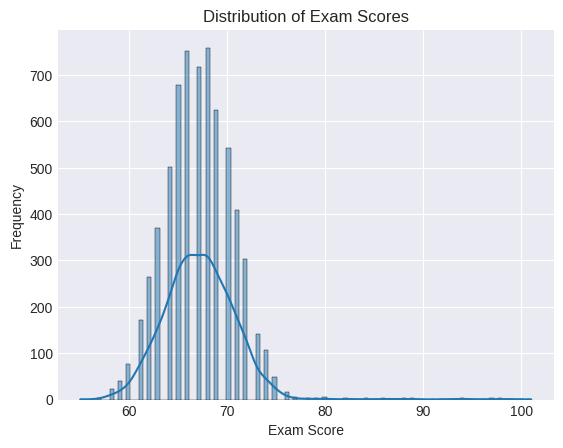

In [10]:
sns.histplot(student_exam['Exam_Score'], kde=True)
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.show()


The histogram of exam scores reveals a **unimodal**, **approximately normal distribution**, with a single peak around 65–70 points. This indicates that many students scored in this range. The distribution is **right‑skewed** indicating a few higher‑scoring students. Overall the performance is consistent with moderate variability and no extreme outliers.


**Hours_Studied:**

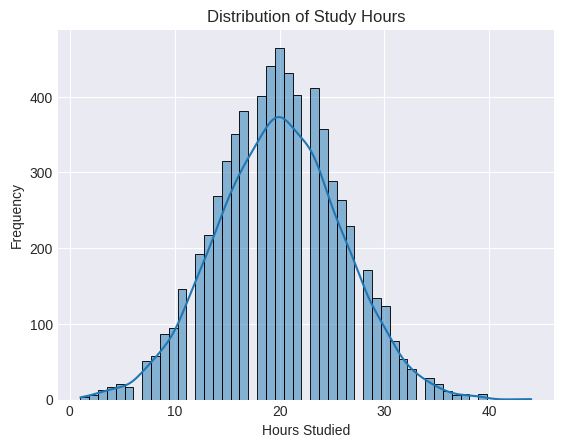

In [11]:
sns.histplot(student_exam['Hours_Studied'], kde=True)
plt.title("Distribution of Study Hours")
plt.xlabel("Hours Studied")
plt.ylabel("Frequency")
plt.show()

The histogram of study hours shows a **normal, symmetric distribution** centered around 20 hours, indicating most students study about this amount. Overall, study patterns are consistent, with moderate variation and no extreme outliers.


**Motivation_Level :**

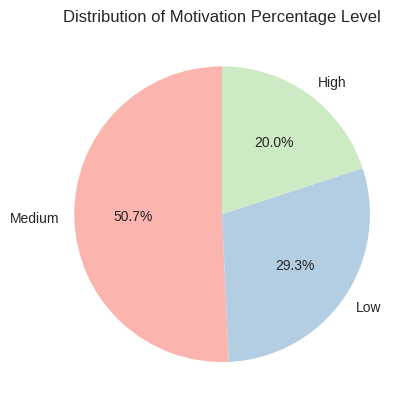

In [12]:
motivation_percentage = student_exam['Motivation_Level'].value_counts(normalize=True) * 100

plt.pie(
    motivation_percentage,
    labels=motivation_percentage.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Pastel1.colors

)

plt.title("Distribution of Motivation Percentage Level")
plt.show()

The pie chart shows that motivation levels are **unevenly distributed**, with most students falling into the **medium motivation** category (50.7%). Meanwhile, 29.3% of students have low motivation, and only 20% demonstrate high motivation. Overall, the distribution suggests that **average motivation is the most common**, while **high motivation is relatively rare**.

## **Bivariate Analysis:**

A bivariate analysis examines two variables to explore the relationship between them.  We will examine these key variables:
* Hours_Studied Vs Exam_Score
* Sleep_Hours Vs Exam_Score
* Parental_Involvement Vs Exam_Score





**Hours_Studied Vs Exam_Score:**

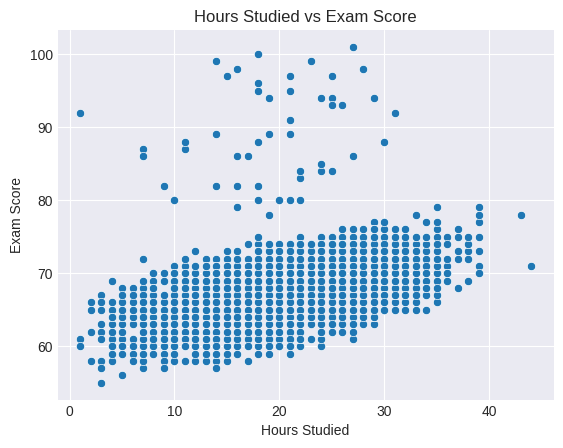

In [13]:
sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=student_exam)
plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.show()

In [14]:
corr, p = pearsonr(student_exam['Hours_Studied'], student_exam['Exam_Score'])
print("The Correlation is:", round(corr,3))
print("The P-value is:", p)

The Correlation is: 0.445
The P-value is: 1.28635e-319


The scatter plot shows a **positive** **relationship** between study hours and exam scores, although the wide spread of points suggests that additional factors beyond study time also influence performance. There is a **moderate positive** **correlation** between hours studied and exam scores (r = 0.445), and the relationship is **statistically significant** (p-value = 1.28635e-319 < 0.05).

**Sleep_Hours Vs Exam_Score:**

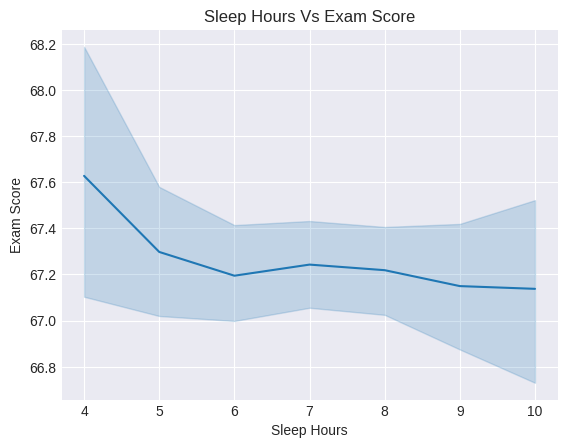

In [15]:
sns.lineplot(x='Sleep_Hours', y='Exam_Score', data=student_exam)
plt.title("Sleep Hours Vs Exam Score")
plt.xlabel("Sleep Hours")
plt.ylabel("Exam Score")
plt.show()


In [16]:
corr, p = pearsonr(student_exam['Sleep_Hours'], student_exam['Exam_Score'])
print("The Correlation is:", round(corr,3))
print("The P-value is:", round(p,3))

The Correlation is: -0.017
The P-value is: 0.167


The line plot shows **no clear trend** between sleep hours and exam scores. The correlation is **extremely weak** (r = –0.017), and the p‑value (0.167 > 0.05) indicates the relationship is **not statistically significant**, meaning sleep hours do not appear to influence exam scores in this dataset.

**Parental_Involvement Vs Exam_Score:**

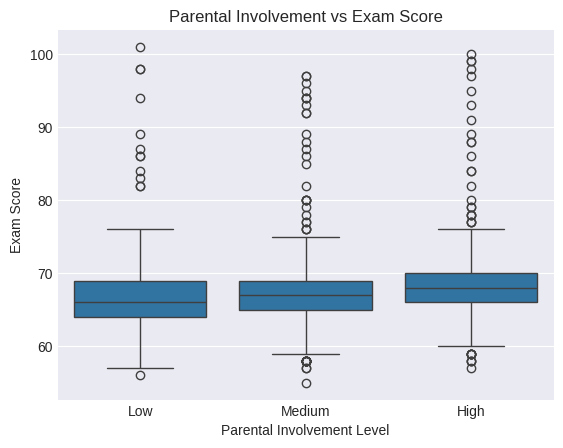

In [17]:
sns.boxplot(x='Parental_Involvement', y='Exam_Score', data=student_exam)
plt.title("Parental Involvement vs Exam Score")
plt.xlabel("Parental Involvement Level")
plt.ylabel("Exam Score")
plt.show()

The boxplot shows that parental involvement has a **significant positive** impact on student performance. Students with **high** parental involvement tend to achieve **higher median** scores leading to a better performance in exams.


# Confirmatory Data Analysis (CDA):
## Statistical Analysis:

**T-test:**

School Type vs Exam Score

**Hypotheses:**

* Null Hypothesis (H₀): There is no difference in the mean exam scores between students in Public and Private schools.
* Alternative Hypothesis (H₁): There is a difference in the mean exam scores between students in Public and Private schools.

In [18]:
public = student_exam[student_exam['School_Type'] == 'Public']['Exam_Score']
private = student_exam[student_exam['School_Type'] == 'Private']['Exam_Score']

t_stat, p_value = stats.ttest_ind(public, private, equal_var=False)
print("The t-test is:", round(t_stat,3))
print("The p-value is:", round(p_value,3))

The t-test is: -0.723
The p-value is: 0.47


The negative t-statistic (t = −0.723) indicates that the mean exam score for Public school students is slightly lower than that of Private school students. However, the p-value (0.47 > 0.05), so we **fail to reject the null hypothesis**. This result is **not statistically significant**, meaning there is no evidence that exam scores differ between Public and Private school students.

**ANOVA:**

Parental_Involvement vs Exam_Score


**Hypoyhesis:**

* Null Hypothesis (H₀): All parental involvement groups have the same mean exam score.
* Alternative Hypothesis (H₁): At least one parental involvement group has a different mean exam score from the others.

In [19]:
low = student_exam[student_exam['Parental_Involvement'] == 'Low']['Exam_Score']
medium = student_exam[student_exam['Parental_Involvement'] == 'Medium']['Exam_Score']
high = student_exam[student_exam['Parental_Involvement'] == 'High']['Exam_Score']

f_stat, p_val = stats.f_oneway(low, medium, high)
print("The F-statistics is:", round(f_stat))
print("The p-value is:", p_val)

The F-statistics is: 84
The p-value is: 5.875479153325444e-37


Since the ANOVA output shows a very large F‑statistic (F = 84) and an extremely small p‑value = 5.875479153325444e-37 < 0.05, we **reject the null hypothesis (H₀)**. This provides **strong statistical evidence** that at least one of the parental involvement groups (Low, Medium, High) has a different mean exam score.

**Post-hoc Test (Tukey HSD):**

ANOVA tells us "At least one of the parental involvement levels has a different mean". But it does NOT tell us which one. That’s why we use post‑hoc tests.


In [20]:
tukey = pairwise_tukeyhsd(
    endog=student_exam['Exam_Score'],
    groups=student_exam['Parental_Involvement'],
    alpha=0.05
)

print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
  High    Low  -1.7345   0.0 -2.0557 -1.4133   True
  High Medium  -0.9946   0.0 -1.2528 -0.7364   True
   Low Medium   0.7399   0.0  0.4487  1.0311   True
---------------------------------------------------


Based on Tukey HSD post‑hoc testing:

* All three pairwise comparisons between parental involvement levels are statistically significant.
* Parental involvement has a strong, graded effect on exam performance:
     * **High vs Low:** High involvement students score higher than Low involvement students.
     * **High vs Medium:** High involvement students score higher than Medium involvement students.
     * **Low vs Medium:** Medium involvement students score higher than Low involvement students.


**Chi‑Square:**

Gender vs Extracurricular_Activities

 **Hypothesis:**
* Null Hypothesis (H₀): There is no association between gender and participation in extracurricular activities.
* Alternative Hypothesis (H₁): There is an association between gender and participation in extracurricular activities.

In [21]:
frequency_table  = pd.crosstab(student_exam['Gender'], student_exam['Extracurricular_Activities'])
chi2, p_value, dof, expected = stats.chi2_contingency(frequency_table)

print("The Chi‑square statistic is:", round(chi2,3))
print("The P-value is:", round(p_value,3))

The Chi‑square statistic is: 0.385
The P-value is: 0.535


Since p = 0.535 > 0.05, we **fail to reject the null hypothesis (H₀)**. This indicates that there is **no statistically significant** association between gender and participation in extracurricular activities. In other words, gender does not appear to influence whether students participate in extracurricular activities.

# Summary & Next Steps:


### Key Findings
* Academic factors: More study hours are linked to higher exam scores.
* Parental involvement: Higher involvement is associated with better performance in exams.
* Lifestyle factors: Sleep shows little to no meaningful effect on exam scores.
* Socio‑Economic & Environmental Factors: School Type (Public vs Private) shows no significant difference in exam scores.
* Gender vs Extracurricular Activities: Gender does not influence participation in extracurricular activities.


### Limitations
* Only Exam_Score is used as the target.
* Missing values in a few columns although they are small (≈1%).
* Strong correlations like study hours do not prove direct causation. Other hidden factors may influence performance.



# **Conclusion:**

This analysis shows acadmic behaviors and parental involvement are the strongest predictors of exam performance. Lifestyle factors like sleep and physical activity show little impact, and socio‑economic variables such as school type or gender do not significantly affect outcomes in this dataset.

Overall, the findings highlight that **consistent study habits and strong parental support** play the most important roles in improving student exam score.